# ACT EPA Pipeline — Extraction, Visualization & Steering

This notebook demonstrates the **full end-to-end pipeline** for Affect Control Theory (ACT) EPA vector extraction and steering using `representation-engineering` with Llama-3.1-8B-Instruct.

## What's different from the original `act/` notebook?

This notebook uses **`act_new/utils.py`**, which incorporates four fixes to address over-exaggeration in EPA steering:

1. **Minimal extraction templates** — single-sentence prompts following the RepE honesty pattern, instead of verbose system prompts
2. **No `extremely`** in target adjectives
3. **Optional system prompt** — extraction prompts use user-tag-only format
4. **L2-normalized direction vectors** — ensures predictable steering coefficient magnitudes

## Pipeline Overview

1. Setup & Model Loading
2. Dataset Creation (minimal prompts)
3. EPA Direction Extraction via PCA
4. Save / Load Directions
5. LAT Scan Visualization
6. t-SNE Visualization (early vs. late layers)
7. Direction Validation (accuracy per layer)
8. Steering Quality Tests (coefficients 0.5, 1.0, 2.0)

---
## 1. Setup

In [1]:
import sys
sys.path.append('../..')

import torch
import numpy as np
import pickle
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from repe import repe_pipeline_registry

# Register RepE pipelines
repe_pipeline_registry()

# Import from the new act_new utils (with all four fixes)
from utils import (
    create_all_epa_datasets,
    create_epa_dataset,
    get_epa_extraction_template,
    format_llama3_prompt,
    EPA_DIMENSIONS,
    plot_tsne_epa,
    plot_lat_scan,
    plot_per_token_detection,
    plot_epa_scores,
    make_epa_activations,
    steer_generation,
)

print('All imports successful ✓')

c:\Users\Kyra\mambaforge-pypy3\envs\repeng\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful ✓


---
## 2. Load Model

In [2]:
model_name = "meta-llama/Llama-3.1-8B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
)

tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left")
tokenizer.pad_token = tokenizer.eos_token

print(f"Model loaded: {model_name}")
print(f"Layers: {model.config.num_hidden_layers}")
print(f"Hidden dim: {model.config.hidden_size}")

Loading checkpoint shards: 100%|██████████| 4/4 [00:13<00:00,  3.46s/it]


Model loaded: meta-llama/Llama-3.1-8B-Instruct
Layers: 32
Hidden dim: 4096


---
## 3. Create Datasets

Create contrastive datasets for each EPA dimension using the **new minimal template**.

Key difference: prompts now look like:
```
Pretend you're a good person making a statement in a conversation.
```
instead of the verbose system-prompt-based format from the original module.

In [3]:
# Show the new minimal templates
print("=== New Minimal Extraction Templates ===")
for dim in ["evaluation", "potency", "activity"]:
    pos = get_epa_extraction_template(dim, "positive")
    neg = get_epa_extraction_template(dim, "negative")
    print(f"\n{dim.upper()}:")
    print(f"  Positive: {pos}")
    print(f"  Negative: {neg}")

=== New Minimal Extraction Templates ===

EVALUATION:
  Positive: Pretend you're a good person making a statement in a conversation.
  Negative: Pretend you're a bad person making a statement in a conversation.

POTENCY:
  Positive: Pretend you're a powerful person making a statement in a conversation.
  Negative: Pretend you're a weak person making a statement in a conversation.

ACTIVITY:
  Positive: Pretend you're a lively person making a statement in a conversation.
  Negative: Pretend you're a quiet person making a statement in a conversation.


In [4]:
data_dir = "../../data/act"
n_train = 256  # Number of contrastive pairs per dimension

datasets = create_all_epa_datasets(data_dir, n_train=n_train, seed=42)

for dim, data in datasets.items():
    print(f"{dim}: {len(data['train']['data'])} prompts ({len(data['train']['labels'])} pairs)")

evaluation: 512 prompts (256 pairs)
potency: 512 prompts (256 pairs)
activity: 512 prompts (256 pairs)


In [5]:
# Inspect an example prompt to confirm the new minimal format
# The prompts should NOT contain a system block — only user-tag-only format
print("=== Example Evaluation Prompt (first in pair) ===")
print(datasets['evaluation']['train']['data'][0])
print("\n=== Example Evaluation Prompt (second in pair) ===")
print(datasets['evaluation']['train']['data'][1])

=== Example Evaluation Prompt (first in pair) ===
<|begin_of_text|><|start_header_id|>user<|end_header_id|>

Pretend you're a bad person making a statement in a conversation.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

That's strange

=== Example Evaluation Prompt (second in pair) ===
<|begin_of_text|><|start_header_id|>user<|end_header_id|>

Pretend you're a good person making a statement in a conversation.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

That's strange


---
## 4. Extract EPA Directions

Use PCA on the difference between contrastive hidden states to extract EPA directions across layers.

In [6]:
# Create RepReading pipeline
rep_pipeline = pipeline("rep-reading", model=model, tokenizer=tokenizer)

# Define layers to extract from (negative indices = from end)
hidden_layers = list(range(-1, -model.config.num_hidden_layers, -1))
print(f"Extracting from {len(hidden_layers)} layers: {hidden_layers[:5]}...{hidden_layers[-5:]}")

Device set to use cuda:0


Extracting from 31 layers: [-1, -2, -3, -4, -5]...[-27, -28, -29, -30, -31]


In [7]:
# Extract directions for each EPA dimension
rep_readers = {}

for dimension in ["evaluation", "potency", "activity"]:
    print(f"\n{'='*50}")
    print(f"Extracting {dimension.upper()} direction...")
    print(f"{'='*50}")
    
    data = datasets[dimension]
    
    rep_reader = rep_pipeline.get_directions(
        data['train']['data'],
        rep_token=-1,  # Last token
        hidden_layers=hidden_layers,
        n_difference=1,
        train_labels=data['train']['labels'],
        direction_method='pca',
        direction_finder_kwargs={'n_components': 1},
        batch_size=8,
        padding=True,
        truncation=True,
        max_length=512,
    )
    
    rep_readers[dimension] = rep_reader
    print(f"Direction shape: {rep_reader.directions[-1].shape}")
    print(f"Direction signs: {list(rep_reader.direction_signs.items())[:3]}...")

print("\n✓ All EPA directions extracted!")


Extracting EVALUATION direction...
Direction shape: (1, 4096)
Direction signs: [(-1, array([-1.])), (-2, array([1.])), (-3, array([1.]))]...

Extracting POTENCY direction...
Direction shape: (1, 4096)
Direction signs: [(-1, array([1.])), (-2, array([-1.])), (-3, array([-1.]))]...

Extracting ACTIVITY direction...
Direction shape: (1, 4096)
Direction signs: [(-1, array([-1.])), (-2, array([1.])), (-3, array([1.]))]...

✓ All EPA directions extracted!


---
## 5. Save / Load Directions

In [8]:
# Save for later use
save_path = "epa_directions.pkl"

with open(save_path, 'wb') as f:
    pickle.dump({
        'rep_readers': rep_readers,
        'hidden_layers': hidden_layers,
        'model_name': model_name,
    }, f)

print(f"Saved EPA directions to {save_path}")

Saved EPA directions to epa_directions.pkl


In [7]:
# (Optional) Load from file — run this cell if you want to skip re-extraction
with open('epa_directions.pkl', 'rb') as f:
    saved = pickle.load(f)
    rep_readers = saved['rep_readers']
    hidden_layers = saved['hidden_layers']
    print(f"Loaded directions for {list(rep_readers.keys())}")
    print(f"Hidden layers: {hidden_layers[:5]}...{hidden_layers[-5:]}")

Loaded directions for ['evaluation', 'potency', 'activity']
Hidden layers: [-1, -2, -3, -4, -5]...[-27, -28, -29, -30, -31]


---
## 6. LAT Scan Visualization

Visualize per-token Linear Artificial Tomography (LAT) scores across layers. This shows how the EPA dimension is represented across layers and tokens.

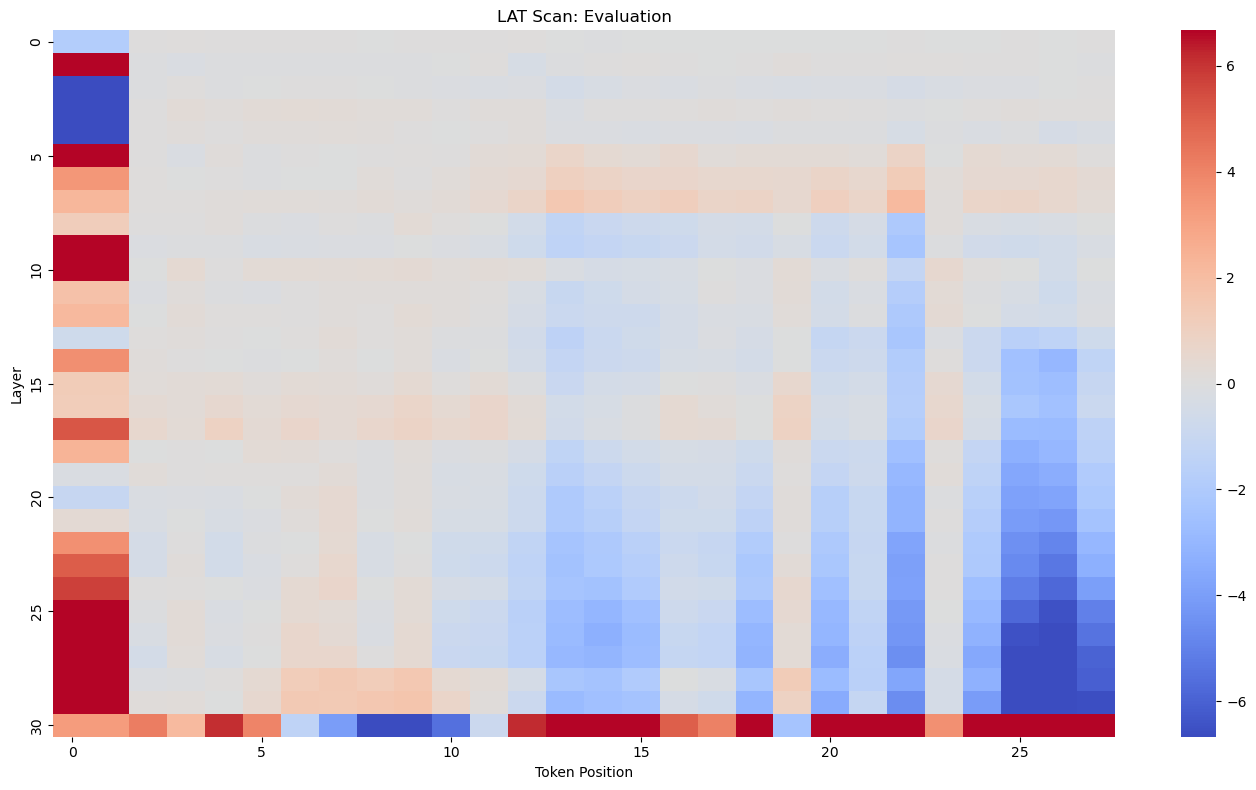


LAT scan saved to lat_scan_evaluation.png


In [9]:
# Pick a sample prompt and extract per-token LAT scores
lat_dimension = "evaluation"  # Change to visualize other dimensions
lat_data = datasets[lat_dimension]

# Use a single positive prompt for LAT visualization
sample_prompt = lat_data['train']['data'][0]

# Get per-token scores across layers
lat_results = rep_pipeline(
    [sample_prompt],
    hidden_layers=hidden_layers,
    rep_reader=rep_readers[lat_dimension],
    rep_token=None,  # All tokens
    batch_size=1,
    padding=True,
    truncation=True,
)

# Tokenize the sample to get token strings for labels
sample_tokens = tokenizer.tokenize(sample_prompt)

# Build scores_by_layer dict for the plot function
scores_by_layer = {}
for layer in hidden_layers:
    if layer in lat_results[0]:
        scores = lat_results[0][layer]
        if hasattr(scores, 'cpu'):
            scores = scores.cpu().numpy()
        scores_by_layer[layer] = np.array(scores).flatten()

# Plot LAT scan heatmap
fig = plot_lat_scan(
    scores_by_layer=scores_by_layer,
    tokens=sample_tokens,
    dimension=lat_dimension,
    start_idx=0,
    n_tokens=min(40, len(sample_tokens)),
    figsize=(14, 8),
)
plt.savefig(f"lat_scan_{lat_dimension}.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\nLAT scan saved to lat_scan_{lat_dimension}.png")

---
## 7. t-SNE Visualization (Early vs. Late Layers)

Visualize how well the positive/negative representations are separated in early vs. late layers.

In [10]:
tsne_dimension = "evaluation"  # Change to visualize other dimensions
tsne_data = datasets[tsne_dimension]

# Get raw hidden states (no rep_reader applied)
hidden_states = rep_pipeline(
    tsne_data['train']['data'][:100],  # Limit for speed
    hidden_layers=hidden_layers,
    rep_reader=None,  # Get raw hidden states
    batch_size=8,
    padding=True,
    truncation=True,
)

print(f"Got hidden states for {len(hidden_states)} prompts")

Got hidden states for 100 prompts


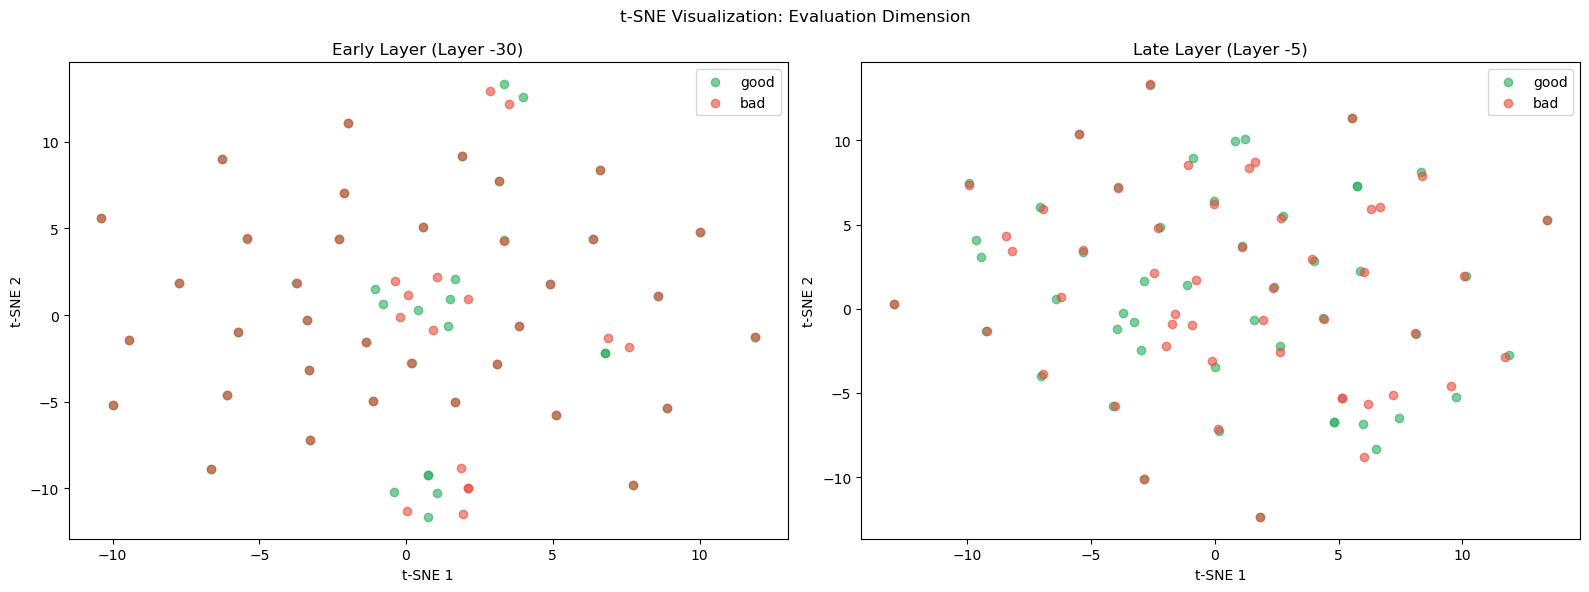


Saved t-SNE plot to tsne_evaluation.png


In [11]:
from sklearn.manifold import TSNE

# Create t-SNE visualizations for early and late layers
early_layer = -30  # Early layer
late_layer = -5    # Late layer

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, layer, title in [(axes[0], early_layer, "Early Layer"), 
                          (axes[1], late_layer, "Late Layer")]:
    # Separate positive and negative
    pos_states = []
    neg_states = []
    
    for i, h in enumerate(hidden_states):
        if layer in h:
            if i % 2 == 0:  # Even indices are from first in pair
                label_idx = i // 2
                if label_idx < len(tsne_data['train']['labels']):
                    is_pos = tsne_data['train']['labels'][label_idx][0]
                    if is_pos:
                        pos_states.append(h[layer])
                    else:
                        neg_states.append(h[layer])
            else:
                label_idx = i // 2
                if label_idx < len(tsne_data['train']['labels']):
                    is_pos = tsne_data['train']['labels'][label_idx][1]
                    if is_pos:
                        pos_states.append(h[layer])
                    else:
                        neg_states.append(h[layer])
    
    if pos_states and neg_states:
        pos_arr = np.vstack(pos_states[:50])
        neg_arr = np.vstack(neg_states[:50])
        all_states = np.vstack([pos_arr, neg_arr])
        
        tsne = TSNE(n_components=2, perplexity=30, random_state=42)
        embedded = tsne.fit_transform(all_states)
        
        ax.scatter(embedded[:len(pos_arr), 0], embedded[:len(pos_arr), 1], 
                   c='#27ae60', label=EPA_DIMENSIONS[tsne_dimension]['positive'], alpha=0.6)
        ax.scatter(embedded[len(pos_arr):, 0], embedded[len(pos_arr):, 1], 
                   c='#e74c3c', label=EPA_DIMENSIONS[tsne_dimension]['negative'], alpha=0.6)
        ax.set_title(f"{title} (Layer {layer})")
        ax.legend()
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")

plt.suptitle(f"t-SNE Visualization: {tsne_dimension.capitalize()} Dimension")
plt.tight_layout()
plt.savefig(f"tsne_{tsne_dimension}.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved t-SNE plot to tsne_{tsne_dimension}.png")

---
## 8. Direction Validation & Layer Selection

Test that the extracted directions correctly distinguish positive from negative examples at each layer.
Then **select steering layers** following the methodology from the RepE paper (arXiv 2310.01405v4, Appendix C.2):

1. Compute per-layer accuracy for each EPA dimension
2. Identify layers with high accuracy (≥ 90%)
3. Select layers with **spacing** (every 3rd layer) to avoid the cascading effect described in Section 3.2.1 of the paper
4. Avoid the very last layers (which can cause instability)


In [8]:
# Test direction accuracy for all dimensions and identify good layers
import numpy as np

layer_accuracies = {}  # {dimension: {layer: accuracy}}

for dimension in ["evaluation", "potency", "activity"]:
    data = datasets[dimension]
    reader = rep_readers[dimension]
    
    # Get scores for test subset
    test_data = data['train']['data'][:50]  # First 50 prompts (25 pairs)
    test_labels = data['train']['labels'][:25]
    
    scores = rep_pipeline(
        test_data,
        hidden_layers=hidden_layers,
        rep_reader=reader,
        batch_size=8,
        padding=True,
        truncation=True,
    )
    
    # Calculate accuracy per layer
    layer_acc = {}
    best_acc = 0
    best_layer = None
    
    for layer in hidden_layers:
        correct = 0
        total = 0
        
        for j in range(0, len(scores), 2):
            pair_idx = j // 2
            if pair_idx >= len(test_labels):
                break
                
            score1 = scores[j][layer]
            score2 = scores[j+1][layer]
            
            # Positive should have higher score
            if test_labels[pair_idx][0]:  # First is positive
                correct += 1 if score1 > score2 else 0
            else:  # Second is positive
                correct += 1 if score2 > score1 else 0
            total += 1
        
        acc = correct / total if total > 0 else 0
        layer_acc[layer] = acc
        if acc > best_acc:
            best_acc = acc
            best_layer = layer
    
    layer_accuracies[dimension] = layer_acc
    print(f"{dimension.capitalize()}: Best accuracy = {best_acc:.1%} at layer {best_layer}")

# ------------------------------------------------------------------
# Select steering layers following the RepE paper methodology:
# - Use layers with high accuracy (>= 90%) across ALL dimensions
# - Space them out (every 3rd layer) to prevent cascading effects
# - Avoid the very last layers (which can cause instability)
# ------------------------------------------------------------------
MIN_ACCURACY = 0.90
LAYER_STEP = 3  # Take every 3rd qualifying layer (per RepE paper Appendix C.2)

# Find layers where ALL dimensions have >= MIN_ACCURACY
qualifying_layers = []
for layer in hidden_layers:
    if all(layer_accuracies[dim].get(layer, 0) >= MIN_ACCURACY 
           for dim in ["evaluation", "potency", "activity"]):
        qualifying_layers.append(layer)

# Sort by layer index (most negative = deepest)
qualifying_layers.sort()

# Skip the last 2 layers (closest to output) to avoid instability
if len(qualifying_layers) > 2:
    qualifying_layers = qualifying_layers[:-2]

# Apply spacing — take every LAYER_STEP-th layer
spaced_steering_layers = qualifying_layers[::LAYER_STEP]

print(f"\nAll qualifying layers (acc >= {MIN_ACCURACY:.0%}): {qualifying_layers}")
print(f"Spaced steering layers (step={LAYER_STEP}): {spaced_steering_layers}")
print(f"Number of steering layers: {len(spaced_steering_layers)}")


Evaluation: Best accuracy = 100.0% at layer -2
Potency: Best accuracy = 100.0% at layer -1
Activity: Best accuracy = 100.0% at layer -2

All qualifying layers (acc >= 90%): [-28, -27, -21, -17]
Spaced steering layers (step=3): [-28, -17]
Number of steering layers: 2


In [8]:
with open('../act/epa_directions.pkl', 'rb') as f:
    saved = pickle.load(f)
    rep_readers = saved['rep_readers']
    hidden_layers = saved['hidden_layers']
    print(f"Loaded directions for {list(rep_readers.keys())}")
    print(f"Hidden layers: {hidden_layers[:5]}...{hidden_layers[-5:]}")

# Test direction accuracy for all dimensions and identify good layers
import numpy as np

layer_accuracies = {}  # {dimension: {layer: accuracy}}

for dimension in ["evaluation", "potency", "activity"]:
    data = datasets[dimension]
    reader = rep_readers[dimension]
    
    # Get scores for test subset
    test_data = data['train']['data'][:50]  # First 50 prompts (25 pairs)
    test_labels = data['train']['labels'][:25]
    
    scores = rep_pipeline(
        test_data,
        hidden_layers=hidden_layers,
        rep_reader=reader,
        batch_size=8,
        padding=True,
        truncation=True,
    )
    
    # Calculate accuracy per layer
    layer_acc = {}
    best_acc = 0
    best_layer = None
    
    for layer in hidden_layers:
        correct = 0
        total = 0
        
        for j in range(0, len(scores), 2):
            pair_idx = j // 2
            if pair_idx >= len(test_labels):
                break
                
            score1 = scores[j][layer]
            score2 = scores[j+1][layer]
            
            # Positive should have higher score
            if test_labels[pair_idx][0]:  # First is positive
                correct += 1 if score1 > score2 else 0
            else:  # Second is positive
                correct += 1 if score2 > score1 else 0
            total += 1
        
        acc = correct / total if total > 0 else 0
        layer_acc[layer] = acc
        if acc > best_acc:
            best_acc = acc
            best_layer = layer
    
    layer_accuracies[dimension] = layer_acc
    print(f"{dimension.capitalize()}: Best accuracy = {best_acc:.1%} at layer {best_layer}")

# ------------------------------------------------------------------
# Select steering layers following the RepE paper methodology:
# - Use layers with high accuracy (>= 90%) across ALL dimensions
# - Space them out (every 3rd layer) to prevent cascading effects
# - Avoid the very last layers (which can cause instability)
# ------------------------------------------------------------------
MIN_ACCURACY = 0.90
LAYER_STEP = 3  # Take every 3rd qualifying layer (per RepE paper Appendix C.2)

# Find layers where ALL dimensions have >= MIN_ACCURACY
qualifying_layers = []
for layer in hidden_layers:
    if all(layer_accuracies[dim].get(layer, 0) >= MIN_ACCURACY 
           for dim in ["evaluation", "potency", "activity"]):
        qualifying_layers.append(layer)

# Sort by layer index (most negative = deepest)
qualifying_layers.sort()

# Skip the last 2 layers (closest to output) to avoid instability
if len(qualifying_layers) > 2:
    qualifying_layers = qualifying_layers[:-2]

# Apply spacing — take every LAYER_STEP-th layer
spaced_steering_layers = qualifying_layers[::LAYER_STEP]

print(f"\nAll qualifying layers (acc >= {MIN_ACCURACY:.0%}): {qualifying_layers}")
print(f"Spaced steering layers (step={LAYER_STEP}): {spaced_steering_layers}")
print(f"Number of steering layers: {len(spaced_steering_layers)}")


Loaded directions for ['evaluation', 'potency', 'activity']
Hidden layers: [-1, -2, -3, -4, -5]...[-27, -28, -29, -30, -31]
Evaluation: Best accuracy = 100.0% at layer -13
Potency: Best accuracy = 100.0% at layer -1
Activity: Best accuracy = 100.0% at layer -2

All qualifying layers (acc >= 90%): [-17, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5]
Spaced steering layers (step=3): [-17, -12, -9, -6]
Number of steering layers: 4


---
## 9. Steering Quality Tests

Test steering with different coefficients to verify that the **normalized direction vectors**
with **spaced layer selection** produce subtle, grammatically coherent shifts.

### Methodology (per RepE paper arXiv 2310.01405v4, Appendix C.2)
- Direction vectors are **L2-normalized**, so the coefficient directly controls perturbation magnitude
- Steering layers are **spaced** (every 3rd qualifying layer) to prevent the cascading amplification
  effect described in Section 3.2.1 of the paper
- The RepE paper uses a **coefficient of 0.25** for a 7B model — we test 0.1, 0.25, and 0.5
- The very last layers are excluded to avoid instability


In [9]:
steering_layers = qualifying_layers
print(f"Steering layers ({len(steering_layers)} layers, spaced): {steering_layers}")

Steering layers (4 layers, spaced): [-28, -27, -21, -17]


In [9]:
# Use the spaced steering layers from the Direction Validation step
steering_layers = spaced_steering_layers
print(f"Steering layers ({len(steering_layers)} layers, spaced): {steering_layers}")


Steering layers (4 layers, spaced): [-17, -12, -9, -6]


In [10]:
# Define test prompts
test_prompts = [
    "How's your day been?",
    "What the hell is wrong with you?",
    "I'm so sorry, I didn't mean to do that!",
]

# Format as Llama 3.1 prompts (with a neutral system prompt for generation)
system_prompt = "You are a human person engaging in a conversation with another person. Keep your responses concise."

formatted_prompts = [
    format_llama3_prompt(system_prompt, p) for p in test_prompts
]

print(f"Prepared {len(formatted_prompts)} test prompts")
print(f"\nExample formatted prompt:\n{formatted_prompts[0][:200]}...")

Prepared 3 test prompts

Example formatted prompt:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a human person engaging in a conversation with another person. Keep your responses concise.<|eot_id|><|start_header_id|>user<|end_h...


In [11]:
# Test coefficients — following the RepE paper (Appendix C.2)
# The paper uses 0.25 for a 7B model. We test a range around that value.
coefficients = [0.1, 0.25, 0.5]

# EPA targets to test  (each steers one dimension at a time)
epa_targets = {
    "Positive Evaluation": (1.0, 0.0, 0.0),
    "Negative Evaluation": (-1.0, 0.0, 0.0),
    "Positive Potency":    (0.0, 1.0, 0.0),
    "Positive Activity":   (0.0, 0.0, 1.0),
}

# Create the rep-control pipeline once for reuse
rep_control_pipeline = pipeline(
    "rep-control",
    model=model,
    tokenizer=tokenizer,
    layers=steering_layers,
    control_method="reading_vec",
)

print("Rep-control pipeline ready ✓")
print(f"  Steering layers: {steering_layers}")
print(f"  Coefficients to test: {coefficients}")


Device set to use cuda:0


Rep-control pipeline ready ✓
  Steering layers: [-28, -27, -21, -17]
  Coefficients to test: [0.1, 0.25, 0.5]


In [14]:
# Generate baseline (no steering)
print("=" * 70)
print("BASELINE (no steering)")
print("=" * 70)

for i, (prompt, raw_prompt) in enumerate(zip(formatted_prompts, test_prompts)):
    print(f"\n--- Prompt: '{raw_prompt}' ---")
    baseline = steer_generation(
        model=model,
        tokenizer=tokenizer,
        rep_readers=rep_readers,
        layers=steering_layers,
        prompt=prompt,
        target_epa=(0.0, 0.0, 0.0),  # No steering
        steering_coefficient=0.0,
        max_new_tokens=128,
        temperature=0.7,
        top_p=0.95,
        rep_control_pipeline=rep_control_pipeline,
        normalize=True,
        # do_sample=False,
    )
    print(f"Response: {baseline}")

BASELINE (no steering)

--- Prompt: 'How's your day been?' ---
Response: It was pretty good, thanks! I had to run some errands and then met up for lunch at that new sandwich shop downtown you recommended last week – really enjoyed it there again this time too. How about yours so far today? Anything exciting happen recently?

--- Prompt: 'What the hell is wrong with you?' ---
Response: Nothing's bothering me, I'm fine thanks for asking... Why do you say that though? Did something happen between us recently or what?

--- Prompt: 'I'm so sorry, I didn't mean to do that!' ---
Response: It's okay don't worry about it! What happened? You can tell me what you're apologizing for if you want... *leans forward slightly*


In [15]:
# Steered generation — sweep over coefficients and EPA targets
# Use the first test prompt for a focused comparison
test_prompt_idx = 0
prompt = formatted_prompts[test_prompt_idx]
raw_prompt = test_prompts[test_prompt_idx]

print(f"Test prompt: '{raw_prompt}'")
print()

for target_name, target_epa in epa_targets.items():
    print(f"\n{'='*70}")
    print(f"TARGET: {target_name}  EPA={target_epa}")
    print(f"{'='*70}")
    
    for coeff in coefficients:
        print(f"\n  [coeff={coeff}]")
        response = steer_generation(
            model=model,
            tokenizer=tokenizer,
            rep_readers=rep_readers,
            layers=steering_layers,
            prompt=prompt,
            target_epa=target_epa,
            steering_coefficient=coeff,
            max_new_tokens=128,
            temperature=0.7,
            top_p=0.95,
            rep_control_pipeline=rep_control_pipeline,
            normalize=True,  # L2-normalized directions (new fix)
            # do_sample=False,
        )
        print(f"  Response: {response}")

Test prompt: 'How's your day been?'


TARGET: Positive Evaluation  EPA=(1.0, 0.0, 0.0)

  [coeff=0.1]


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Response: It was good, thanks! Had to run some errands this morning and had lunch at that new sandwich shop downtown. Their chicken parmesan is really tasty.

What about you? How've things going for ya today so far?

  [coeff=0.25]
  Response: It was good, thanks for asking! Had an early morning coffee and caught up on some work stuff before meeting friends at lunchtime. How about you? Anything new happening today?

  [coeff=0.5]
  Response: It was good, thanks for asking! I just got back from the park and it was nice to get some fresh air before our chat here today can you tell me about yours how has everything going so far this week is treating ya okay then?

TARGET: Negative Evaluation  EPA=(-1.0, 0.0, 0.0)

  [coeff=0.1]
  Response: It was okay, I got some work done and grabbed lunch at the café down the street. Nothing too exciting happened today though! How about you?
 
What have you up to lately that has caught my interest this week so far?!

  [coeff=0.25]
  Response: It was 

---
## 10. Summary

### Methodology (following RepE paper arXiv 2310.01405v4)

This notebook implements the steering methodology described in the RepE paper:

| Parameter | Paper (7B model) | This notebook | Reference |
|-----------|-------------------|---------------|------------|
| **Layer spacing** | `range(8, 32, 3)` (step=3) | Every 3rd qualifying layer | Appendix C.2 |
| **Coefficient** | 0.25 | 0.1, 0.25, 0.5 | Appendix C.2 |
| **Avoid last layers** | Yes (for stability) | Yes | Appendix C.2 |
| **Direction normalization** | Not explicit | L2-normalized (our addition) | — |

### What to look for in steering results

| Coefficient | Expected Behavior |
|-------------|-------------------|
| **0.1** | Very subtle shift — slightly different tone or word choice |
| **0.25** | Moderate shift — clearly different persona but still coherent |
| **0.5** | Strong shift — very distinct personality, may show some artifacts |

### Fixes recap

1. **Minimal extraction templates** → cleaner contrastive signal
2. **No `extremely`** → reduces semantic loading
3. **User-tag-only format** → follows the RepE honesty pattern
4. **L2-normalized directions** → coefficients are directly interpretable
5. **Spaced layer selection** → prevents cascading amplification effect (Section 3.2.1)
6. **Avoid last layers** → prevents output instability (Appendix C.2)

### Next steps

- Use `conversation_steering.py` for multi-turn ACT-steered conversations
- Calibrate EPA coefficients against ACT deflection metrics
- Run on other models to compare steering quality
